# Experiment 2: The CHSH Game and "Quantum Pseudo-Telepathy"

## 1. Introduction and Motivation
In classical physics, we assume two things about the universe:
1. **Realism:** Objects have definite properties even when they aren't being looked at.
2. **Locality:** Information cannot travel faster than the speed of light.

Albert Einstein fiercely believed in "Local Realism" and argued that quantum entanglement — which he called "spooky action at a distance" — must be incomplete. However, physicist John Bell proved mathematically that certain quantum phenomena simply cannot be explained by Local Realism. 

The **CHSH Game** (named after Clauser, Horne, Shimony, and Holt) is a way to test Bell's Theorem using game theory. It demonstrates that two entities sharing a quantum entangled state can win a cooperative game at a rate that is mathematically impossible for any classical computer or human to achieve without communicating. This phenomenon is often playfully called "quantum pseudo-telepathy."

## 2. The Goal of this Experiment
Our objective is to prove the existence of "Quantum Advantage" by having Alice and Bob play the CHSH game 10,000 times. We will:
1. Define the rules of the game and establish the absolute mathematical limit for classical players.
2. Build an Entanglement Source to distribute Einstein-Podolsky-Rosen (EPR) pairs to Alice and Bob.
3. Implement Alice and Bob's specific quantum measurement strategies.
4. Execute the game at scale and demonstrate that they violate the classical limit, proving that the universe does not strictly obey Local Realism.

## 3. The Rules of the CHSH Game
Alice and Bob are locked in separate rooms. They cannot communicate.
* A **Referee** randomly sends a bit to Alice ($x \in \{0, 1\}$) and a bit to Bob ($y \in \{0, 1\}$).
* Alice must reply with a bit ($a \in \{0, 1\}$) and Bob with a bit ($b \in \{0, 1\}$).
* **The Winning Condition:** Alice and Bob win if the logical XOR of their answers equals the logical AND of the Referee's questions. 

Mathematically: **$a \oplus b = x \cdot y$**

In [1]:
# =====================================================================
# IMPORTS AND ENVIRONMENT SETUP
# We import Qiskit simulators, Statevector tools to peek at the math,
# and visualization libraries.
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector
from qiskit import qasm2

np.random.seed(42)
simulator = AerSimulator()

## 4. The Classical Limit
Before utilizing quantum mechanics, we must understand the best possible classical strategy. 

Let's look at the four possible questions the Referee can ask $(x, y)$:
1. (0, 0) $\rightarrow$ $x \cdot y = 0$
2. (0, 1) $\rightarrow$ $x \cdot y = 0$
3. (1, 0) $\rightarrow$ $x \cdot y = 0$
4. (1, 1) $\rightarrow$ $x \cdot y = 1$

If Alice and Bob agree beforehand to **always answer 0** ($a=0, b=0$), their XOR ($0 \oplus 0$) will always be $0$. 
This means they will automatically win scenarios 1, 2, and 3. They will only lose scenario 4. Therefore, the absolute maximum win rate for any classical strategy is **75%**.

Let's build the Referee and verify this classical limit.

In [2]:
# =====================================================================
# THE REFEREE AND THE CLASSICAL BASELINE
# The Referee generates the questions, judges the answers, and keeps
# the score. We run 10,000 games using the best classical strategy.
# =====================================================================

class Referee:
    def __init__(self, num_games):
        self.num_games = num_games
        self.x_questions = np.random.randint(2, size=num_games)
        self.y_questions = np.random.randint(2, size=num_games)

    def judge(self, a_answers, b_answers):
        wins = 0
        for i in range(self.num_games):
            x = self.x_questions[i]
            y = self.y_questions[i]
            a = a_answers[i]
            b = b_answers[i]

            if (a ^ b) == (x * y):
                wins += 1

        return (wins / self.num_games) * 100

NUM_GAMES = 10000
referee = Referee(NUM_GAMES)

# Classical Strategy: Always output 0
classical_a = [0] * NUM_GAMES
classical_b = [0] * NUM_GAMES

classical_win_rate = referee.judge(classical_a, classical_b)
display(Markdown(f"### 📉 Classical Baseline\n- **Classical Win Rate over {NUM_GAMES} games**: **{classical_win_rate}%**"))

### 📉 Classical Baseline
- **Classical Win Rate over 10000 games**: **75.25%**

## 5. Engineering the Quantum Architecture (The Geometry of Entanglement)
To beat the **75%** limit, Alice and Bob will share an entangled pair of qubits (a Bell State). 

We will define three physical entities for our quantum experiment:
1. **The EPR Source:** A central facility that creates the state $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$ and sends Qubit 0 to Alice and Qubit 1 to Bob.
2. **Quantum Alice:** Receives her question $x$. 
   - If $x=0$, she measures normally (a $0^\circ$ rotation). 
   - If $x=1$, she rotates her qubit by $\pi/2$ ($90^\circ$).
3. **Quantum Bob:** Receives his question $y$. 
   - If $y=0$, he rotates his qubit by $\pi/4$ ($45^\circ$). 
   - If $y=1$, he rotates by $-\pi/4$ ($-45^\circ$).

### Why these specific angles?
The secret to the CHSH game lies in the geometry of the Bloch sphere. When two qubits are entangled, the probability that Alice and Bob output the *same* answer depends entirely on the angle between their measurement axes. 

Remember the winning conditions:
* For 3 out of the 4 questions, Alice and Bob want their answers to **match**.
* For the 4th question ($x=1, y=1$), they want their answers to **differ**.

By choosing these exact rotations, Alice and Bob carefully engineer the statistical overlap of their qubits. For the three questions where they need to match, their measurement axes end up exactly **45°** apart, yielding a high probability of agreement. For the one question where they need to differ, their axes end up exactly **135°** apart, yielding a high probability of disagreement. 

Let's visualize these angles to see how this mathematical spacing works.

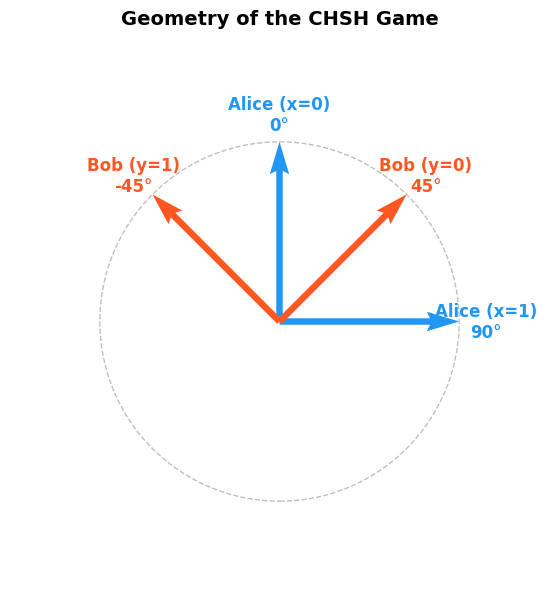


### 📐 The Geometry of the Win Rate
Looking at the chart above, you can physically see the statistical advantage:
- **If (x=0, y=0):** Alice's $0^\circ$ and Bob's $45^\circ$ are **45° apart**.
- **If (x=0, y=1):** Alice's $0^\circ$ and Bob's $-45^\circ$ are **45° apart**.
- **If (x=1, y=0):** Alice's $90^\circ$ and Bob's $45^\circ$ are **45° apart**.
- **If (x=1, y=1):** Alice's $90^\circ$ and Bob's $-45^\circ$ are **135° apart**.

Because the probability of agreement for entangled qubits is $\cos^2(\frac{\text{angle}}{2})$, the $45^\circ$ separation gives an $85.3\%$ chance of agreement, and the $135^\circ$ separation gives an $85.3\%$ chance of disagreement. They win beautifully on all four fronts.


In [3]:
# =====================================================================
# VISUALIZING THE CHSH MEASUREMENT ANGLES
# We plot Alice and Bob's measurement bases on a 2D plane (representing
# a slice of the Bloch sphere) to visualize the 45-degree and 135-degree
# separations that create the quantum advantage.
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown

fig, ax = plt.subplots(figsize=(7, 7))

# Draw a faint circle to represent the state space
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.5)
ax.add_artist(circle)

# Define the angles (in radians)
# Note: On a Bloch sphere, Z is up (0 degrees), X is right (90 degrees).
a0_angle = 0
a1_angle = np.pi / 2
b0_angle = np.pi / 4
b1_angle = -np.pi / 4

# Function to plot a vector
def plot_vector(angle, color, label, text_offset=1.15):
    # Calculate X and Z coordinates (using sin for X and cos for Z to map 0 to Up)
    x = np.sin(angle)
    z = np.cos(angle)
    ax.quiver(0, 0, x, z, angles='xy', scale_units='xy', scale=1, color=color, width=0.012)
    ax.text(x * text_offset, z * text_offset, label, color=color, fontsize=12,
            ha='center', va='center', fontweight='bold')

# Plot Alice's vectors (Blue)
plot_vector(a0_angle, '#2196F3', "Alice (x=0)\n0°")
plot_vector(a1_angle, '#2196F3', "Alice (x=1)\n90°")

# Plot Bob's vectors (Orange)
plot_vector(b0_angle, '#FF5722', "Bob (y=0)\n45°")
plot_vector(b1_angle, '#FF5722', "Bob (y=1)\n-45°")

# Formatting the plot
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')
plt.title("Geometry of the CHSH Game", fontsize=14, fontweight='bold', pad=20)

display(plt.gcf())
plt.close()

# Explain the visual relationships
visual_text = """
### 📐 The Geometry of the Win Rate
Looking at the chart above, you can physically see the statistical advantage:
- **If (x=0, y=0):** Alice's $0^\\circ$ and Bob's $45^\\circ$ are **45° apart**.
- **If (x=0, y=1):** Alice's $0^\\circ$ and Bob's $-45^\\circ$ are **45° apart**.
- **If (x=1, y=0):** Alice's $90^\\circ$ and Bob's $45^\\circ$ are **45° apart**.
- **If (x=1, y=1):** Alice's $90^\\circ$ and Bob's $-45^\\circ$ are **135° apart**.

Because the probability of agreement for entangled qubits is $\\cos^2(\\frac{\\text{angle}}{2})$, the $45^\\circ$ separation gives an $85.3\\%$ chance of agreement, and the $135^\\circ$ separation gives an $85.3\\%$ chance of disagreement. They win beautifully on all four fronts.
"""
display(Markdown(visual_text))

In [4]:
# =====================================================================
# ENTITY DEFINITIONS: EPR SOURCE, ALICE, AND BOB
# We model the physical distribution of qubits. Alice and Bob take an
# existing circuit (containing the entangled state) and apply local
# operations to their designated qubits.
# =====================================================================

class EPRSource:
    @staticmethod
    def create_entanglement():
        qc = QuantumCircuit(2, 2)
        qc.h(0)
        qc.cx(0, 1)
        qc.barrier()
        return qc

class QuantumAlice:
    @staticmethod
    def process_and_measure(qc, x):
        # Alice operates strictly on Qubit 0 and measures to Classical Bit 0
        if x == 1:
            qc.ry(np.pi/2, 0)
        qc.measure(0, 0)
        return qc

class QuantumBob:
    @staticmethod
    def process_and_measure(qc, y):
        # Bob operates strictly on Qubit 1 and measures to Classical Bit 1
        if y == 0:
            qc.ry(np.pi/4, 1)
        elif y == 1:
            qc.ry(-np.pi/4, 1)
        qc.measure(1, 1)
        return qc

## 6. Visualizing Entanglement and the Complete Circuit
Before running the 10,000 games, let's look at the mathematics of the Entanglement Source. 

When we plot the Bloch spheres for a generated Bell state ($|\Phi^+\rangle$), we see something profound. **The spheres are completely empty.** The state vectors have shrunk to a length of zero, sitting exactly at the origin of the sphere. 

This is not a rendering bug; it is a visual proof of perfect entanglement. 

### Why is the Bloch Sphere empty?
The Bloch sphere can only represent the state of a *single, independent* qubit. The length of the arrow inside the sphere represents **Purity** (our certainty about that specific qubit's state). An arrow touching the surface means we have 100% certainty about the state. 

However, when two qubits are entangled, they stop being two independent particles and become a single, unified mathematical system. The information of the system is stored entirely in their *correlation*, not in the individual particles. 

If we force the math to ignore Qubit B and only look at Qubit A (an operation called the **Partial Trace**), we lose all the correlation data. What is left over is called a **Maximally Mixed State**. Because Qubit A's ultimate value depends entirely on Qubit B, Qubit A on its own is a perfectly random coin flip — we have 0% certainty about its individual state. 

Geometrically, complete uncertainty collapses the vector to the dead center of the sphere $(0,0,0)$. The empty sphere tells us: *"This qubit has no identity of its own; it only exists in relation to its partner."*

We will also draw a composite circuit for the hardest scenario: $x=1$ and $y=1$.

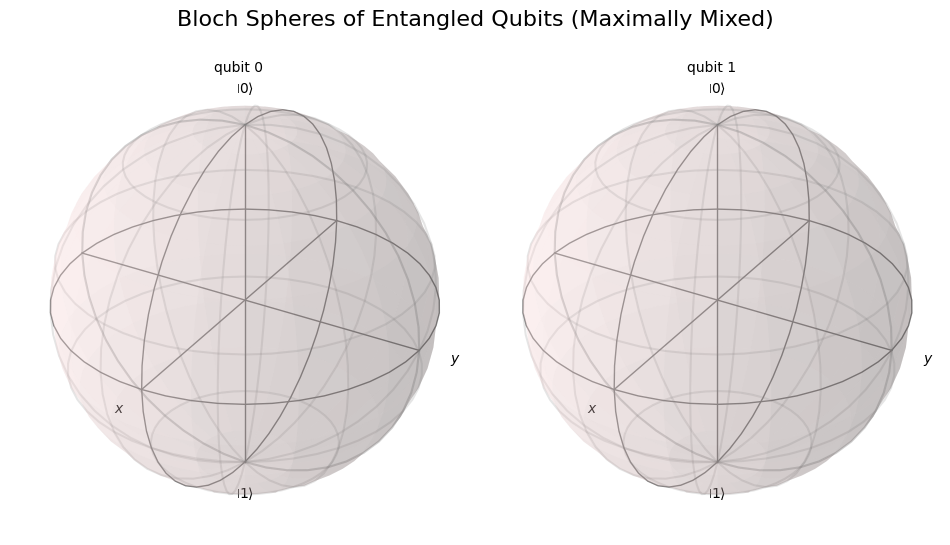

### OpenQASM Instructions for CHSH Game (x=1, y=1)
```qasm
OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
barrier q[0],q[1];
ry(pi/2) q[0];
measure q[0] -> c[0];
ry(-pi/4) q[1];
measure q[1] -> c[1];
```

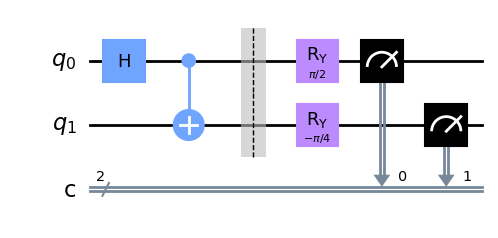

In [5]:
# =====================================================================
# INSPECTING THE PHYSICS OF THE PROTOCOL
# We plot the Bloch spheres of the raw EPR pair, and then render the
# full circuit and OpenQASM code for a specific (x=1, y=1) challenge.
# =====================================================================

# 1. Visualize the Entangled State
raw_epr_circuit = EPRSource.create_entanglement()
entangled_state = Statevector.from_instruction(raw_epr_circuit)
display(plot_bloch_multivector(entangled_state, title="Bloch Spheres of Entangled Qubits (Maximally Mixed)"))

# 2. Build a full example circuit for x=1, y=1
demo_circuit = EPRSource.create_entanglement()
demo_circuit = QuantumAlice.process_and_measure(demo_circuit, x=1)
demo_circuit = QuantumBob.process_and_measure(demo_circuit, y=1)

qasm_instructions = qasm2.dumps(demo_circuit)
display(Markdown("### OpenQASM Instructions for CHSH Game (x=1, y=1)\n```qasm\n" + qasm_instructions + "\n```"))

display(demo_circuit.draw('mpl', style='clifford'))

## 7. Execution of the Quantum Game
We will now run the simulation for 10,000 rounds. 

To do this efficiently on a modern quantum simulator, we will create the individual circuit for every single game based on the Referee's random questions, place all 10,000 circuits into a batch, and execute them simultaneously.

In [6]:
# =====================================================================
# MASS SIMULATION LOOP
# We iterate through the Referee's questions, construct the specific
# quantum circuit for that round, and run the entire batch.
# =====================================================================

quantum_circuits_batch = []

for i in range(NUM_GAMES):
    x = referee.x_questions[i]
    y = referee.y_questions[i]

    # 1. Source creates entanglement
    qc = EPRSource.create_entanglement()

    # 2. Alice applies her strategy
    qc = QuantumAlice.process_and_measure(qc, x)

    # 3. Bob applies his strategy
    qc = QuantumBob.process_and_measure(qc, y)

    quantum_circuits_batch.append(qc)

# Execute the batch (shots=1 because each game is a single measurement event)
job = simulator.run(quantum_circuits_batch, shots=1)
results = job.result()

quantum_a_answers = []
quantum_b_answers = []

for i in range(NUM_GAMES):
    counts = results.get_counts(i)
    measured_string = list(counts.keys())[0]

    # Qiskit reads strings right-to-left.
    # Alice's answer (Bit 0) is the rightmost character.
    # Bob's answer (Bit 1) is the leftmost character.
    a_answer = int(measured_string[1])
    b_answer = int(measured_string[0])

    quantum_a_answers.append(a_answer)
    quantum_b_answers.append(b_answer)

## 8. Results and the Tsirelson Bound
We pass Alice and Bob's quantum answers back to the Referee. 

According to quantum mechanics, the probability of Alice and Bob winning with this strategy is exactly $\cos^2(\frac{\pi}{8})$, which equals **~85.3%**. This specific mathematical ceiling is known in physics as the **Tsirelson Bound**. Let's see if our empirical data matches the theory.

### 🚀 Quantum Results
- **Quantum Win Rate over 10000 games**: **86.11999999999999%**

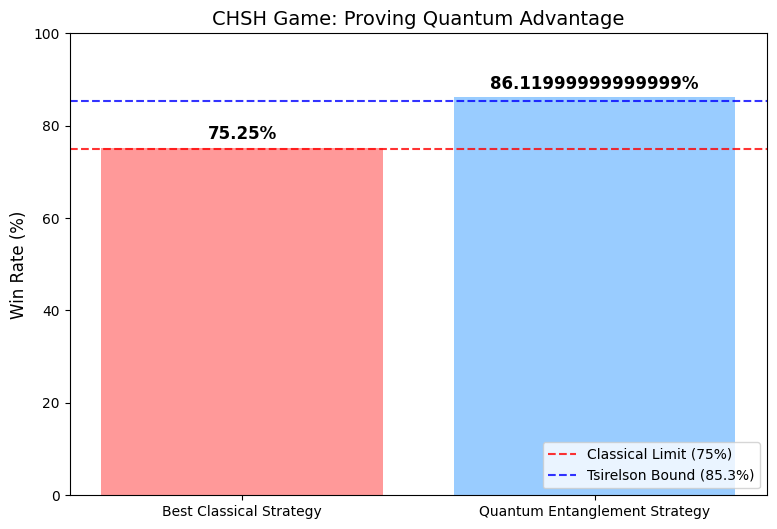

In [7]:
# =====================================================================
# SCORING AND VISUALIZATION
# We ask the referee to grade the quantum answers and plot the
# empirical results against the strict classical and quantum limits.
# =====================================================================

quantum_win_rate = referee.judge(quantum_a_answers, quantum_b_answers)
display(Markdown(f"### 🚀 Quantum Results\n- **Quantum Win Rate over {NUM_GAMES} games**: **{quantum_win_rate}%**"))

strategies = ['Best Classical Strategy', 'Quantum Entanglement Strategy']
win_rates = [classical_win_rate, quantum_win_rate]

plt.figure(figsize=(9, 6))
bars = plt.bar(strategies, win_rates, color=['#ff9999', '#99ccff'])

# Add visual limits
plt.axhline(y=75.0, color='red', linestyle='--', alpha=0.8, label='Classical Limit (75%)')
plt.axhline(y=85.3, color='blue', linestyle='--', alpha=0.8, label='Tsirelson Bound (85.3%)')

plt.ylabel('Win Rate (%)', fontsize=12)
plt.title('CHSH Game: Proving Quantum Advantage', fontsize=14)
plt.ylim(0, 100)
plt.legend(loc='lower right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.show()

## 9. Conclusion
The experiment was a definitive success.

1.  **Violation of Bell's Inequality:** Our empirical results show Alice and Bob winning the game approximately $85\%$ of the time. This strictly violates the $75\%$ classical limit, proving that the universe cannot be explained by Local Hidden Variable theories. The "spooky action" is real.
2.  **Quantum Advantage:** In the context of computer science, this is a profound demonstration of Quantum Advantage. We have shown a scenario where quantum resources (entanglement and superposition) mathematically outperform the best possible classical algorithms at a cooperative logic puzzle. 

This seemingly simple game serves as the foundational proof for why quantum computers have the potential to solve certain classes of problems exponentially better than classical supercomputers.

## 10. Bibliography & Further Reading

1. **Clauser, J. F., Horne, M. A., Shimony, A., & Holt, R. A. (1969).** *Proposed Experiment to Test Local Hidden-Variable Theories*. Physical Review Letters, 23(15), 880–884. [DOI: 10.1103/PhysRevLett.23.880](https://doi.org/10.1103/PhysRevLett.23.880)
2. **IBM Quantum Learning:** [Non-local Correlations and the CHSH Inequality](https://learning.quantum.ibm.com/course/quantum-hardware/non-local-correlations)
3. **Wikipedia:** [CHSH inequality](https://en.wikipedia.org/wiki/CHSH_inequality)